In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Column names from the readme
col_names = ['engine_id', 'cycle', 
             'setting1', 'setting2', 'setting3',
             's1','s2','s3','s4','s5','s6','s7',
             's8','s9','s10','s11','s12','s13',
             's14','s15','s16','s17','s18','s19',
             's20','s21']

# Load — the file has trailing spaces so we get phantom columns, drop them
df = pd.read_csv('../data/raw/train_FD001.txt', 
                  sep='\s+', 
                  header=None,
                  names=col_names)

print(df.shape)
print(df.head())

(20631, 26)
   engine_id  cycle  setting1  setting2  setting3      s1      s2       s3  \
0          1      1   -0.0007   -0.0004     100.0  518.67  641.82  1589.70   
1          1      2    0.0019   -0.0003     100.0  518.67  642.15  1591.82   
2          1      3   -0.0043    0.0003     100.0  518.67  642.35  1587.99   
3          1      4    0.0007    0.0000     100.0  518.67  642.35  1582.79   
4          1      5   -0.0019   -0.0002     100.0  518.67  642.37  1582.85   

        s4     s5  ...     s12      s13      s14     s15   s16  s17   s18  \
0  1400.60  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388   
1  1403.14  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388   
2  1404.20  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388   
3  1401.87  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388   
4  1406.22  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388   

     s19    s20      s21  
0  100.0  39.06  23.4190  
1 

In [3]:
# For each engine, find its last cycle (the failure point)
max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

# Merge back and compute RUL
df = df.merge(max_cycles, on='engine_id')
df['RUL'] = df['max_cycle'] - df['cycle']
df.drop(columns=['max_cycle'], inplace=True)

print(df[['engine_id', 'cycle', 'RUL']].head(20))

    engine_id  cycle  RUL
0           1      1  191
1           1      2  190
2           1      3  189
3           1      4  188
4           1      5  187
5           1      6  186
6           1      7  185
7           1      8  184
8           1      9  183
9           1     10  182
10          1     11  181
11          1     12  180
12          1     13  179
13          1     14  178
14          1     15  177
15          1     16  176
16          1     17  175
17          1     18  174
18          1     19  173
19          1     20  172


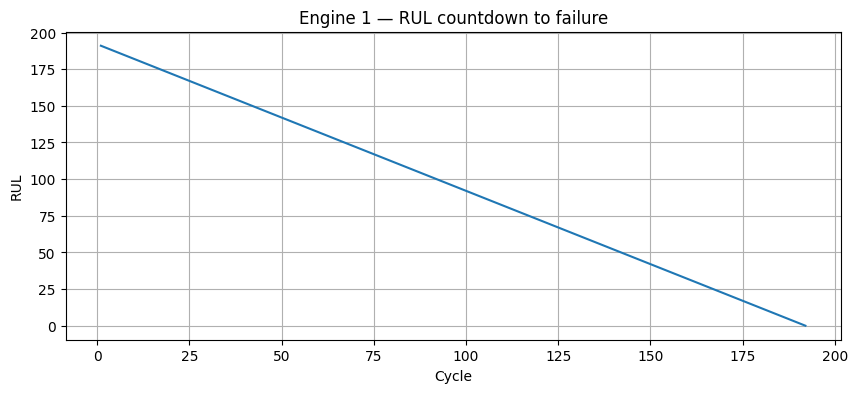

In [4]:
engine_1 = df[df['engine_id'] == 1][['cycle', 'RUL']]

plt.figure(figsize=(10, 4))
plt.plot(engine_1['cycle'], engine_1['RUL'])
plt.xlabel('Cycle')
plt.ylabel('RUL')
plt.title('Engine 1 — RUL countdown to failure')
plt.grid(True)
plt.show()

In [5]:
print(df.isnull().sum())

engine_id    0
cycle        0
setting1     0
setting2     0
setting3     0
s1           0
s2           0
s3           0
s4           0
s5           0
s6           0
s7           0
s8           0
s9           0
s10          0
s11          0
s12          0
s13          0
s14          0
s15          0
s16          0
s17          0
s18          0
s19          0
s20          0
s21          0
RUL          0
dtype: int64


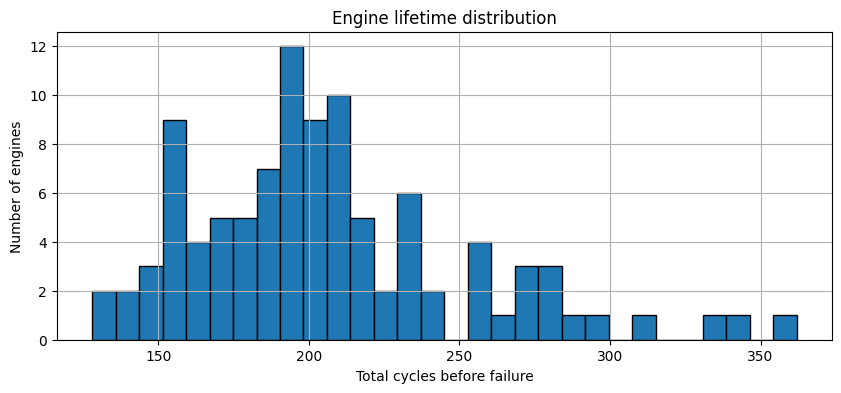

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


In [6]:
engine_lifetimes = df.groupby('engine_id')['cycle'].max()

plt.figure(figsize=(10, 4))
plt.hist(engine_lifetimes, bins=30, edgecolor='black')
plt.xlabel('Total cycles before failure')
plt.ylabel('Number of engines')
plt.title('Engine lifetime distribution')
plt.grid(True)
plt.show()

print(engine_lifetimes.describe())

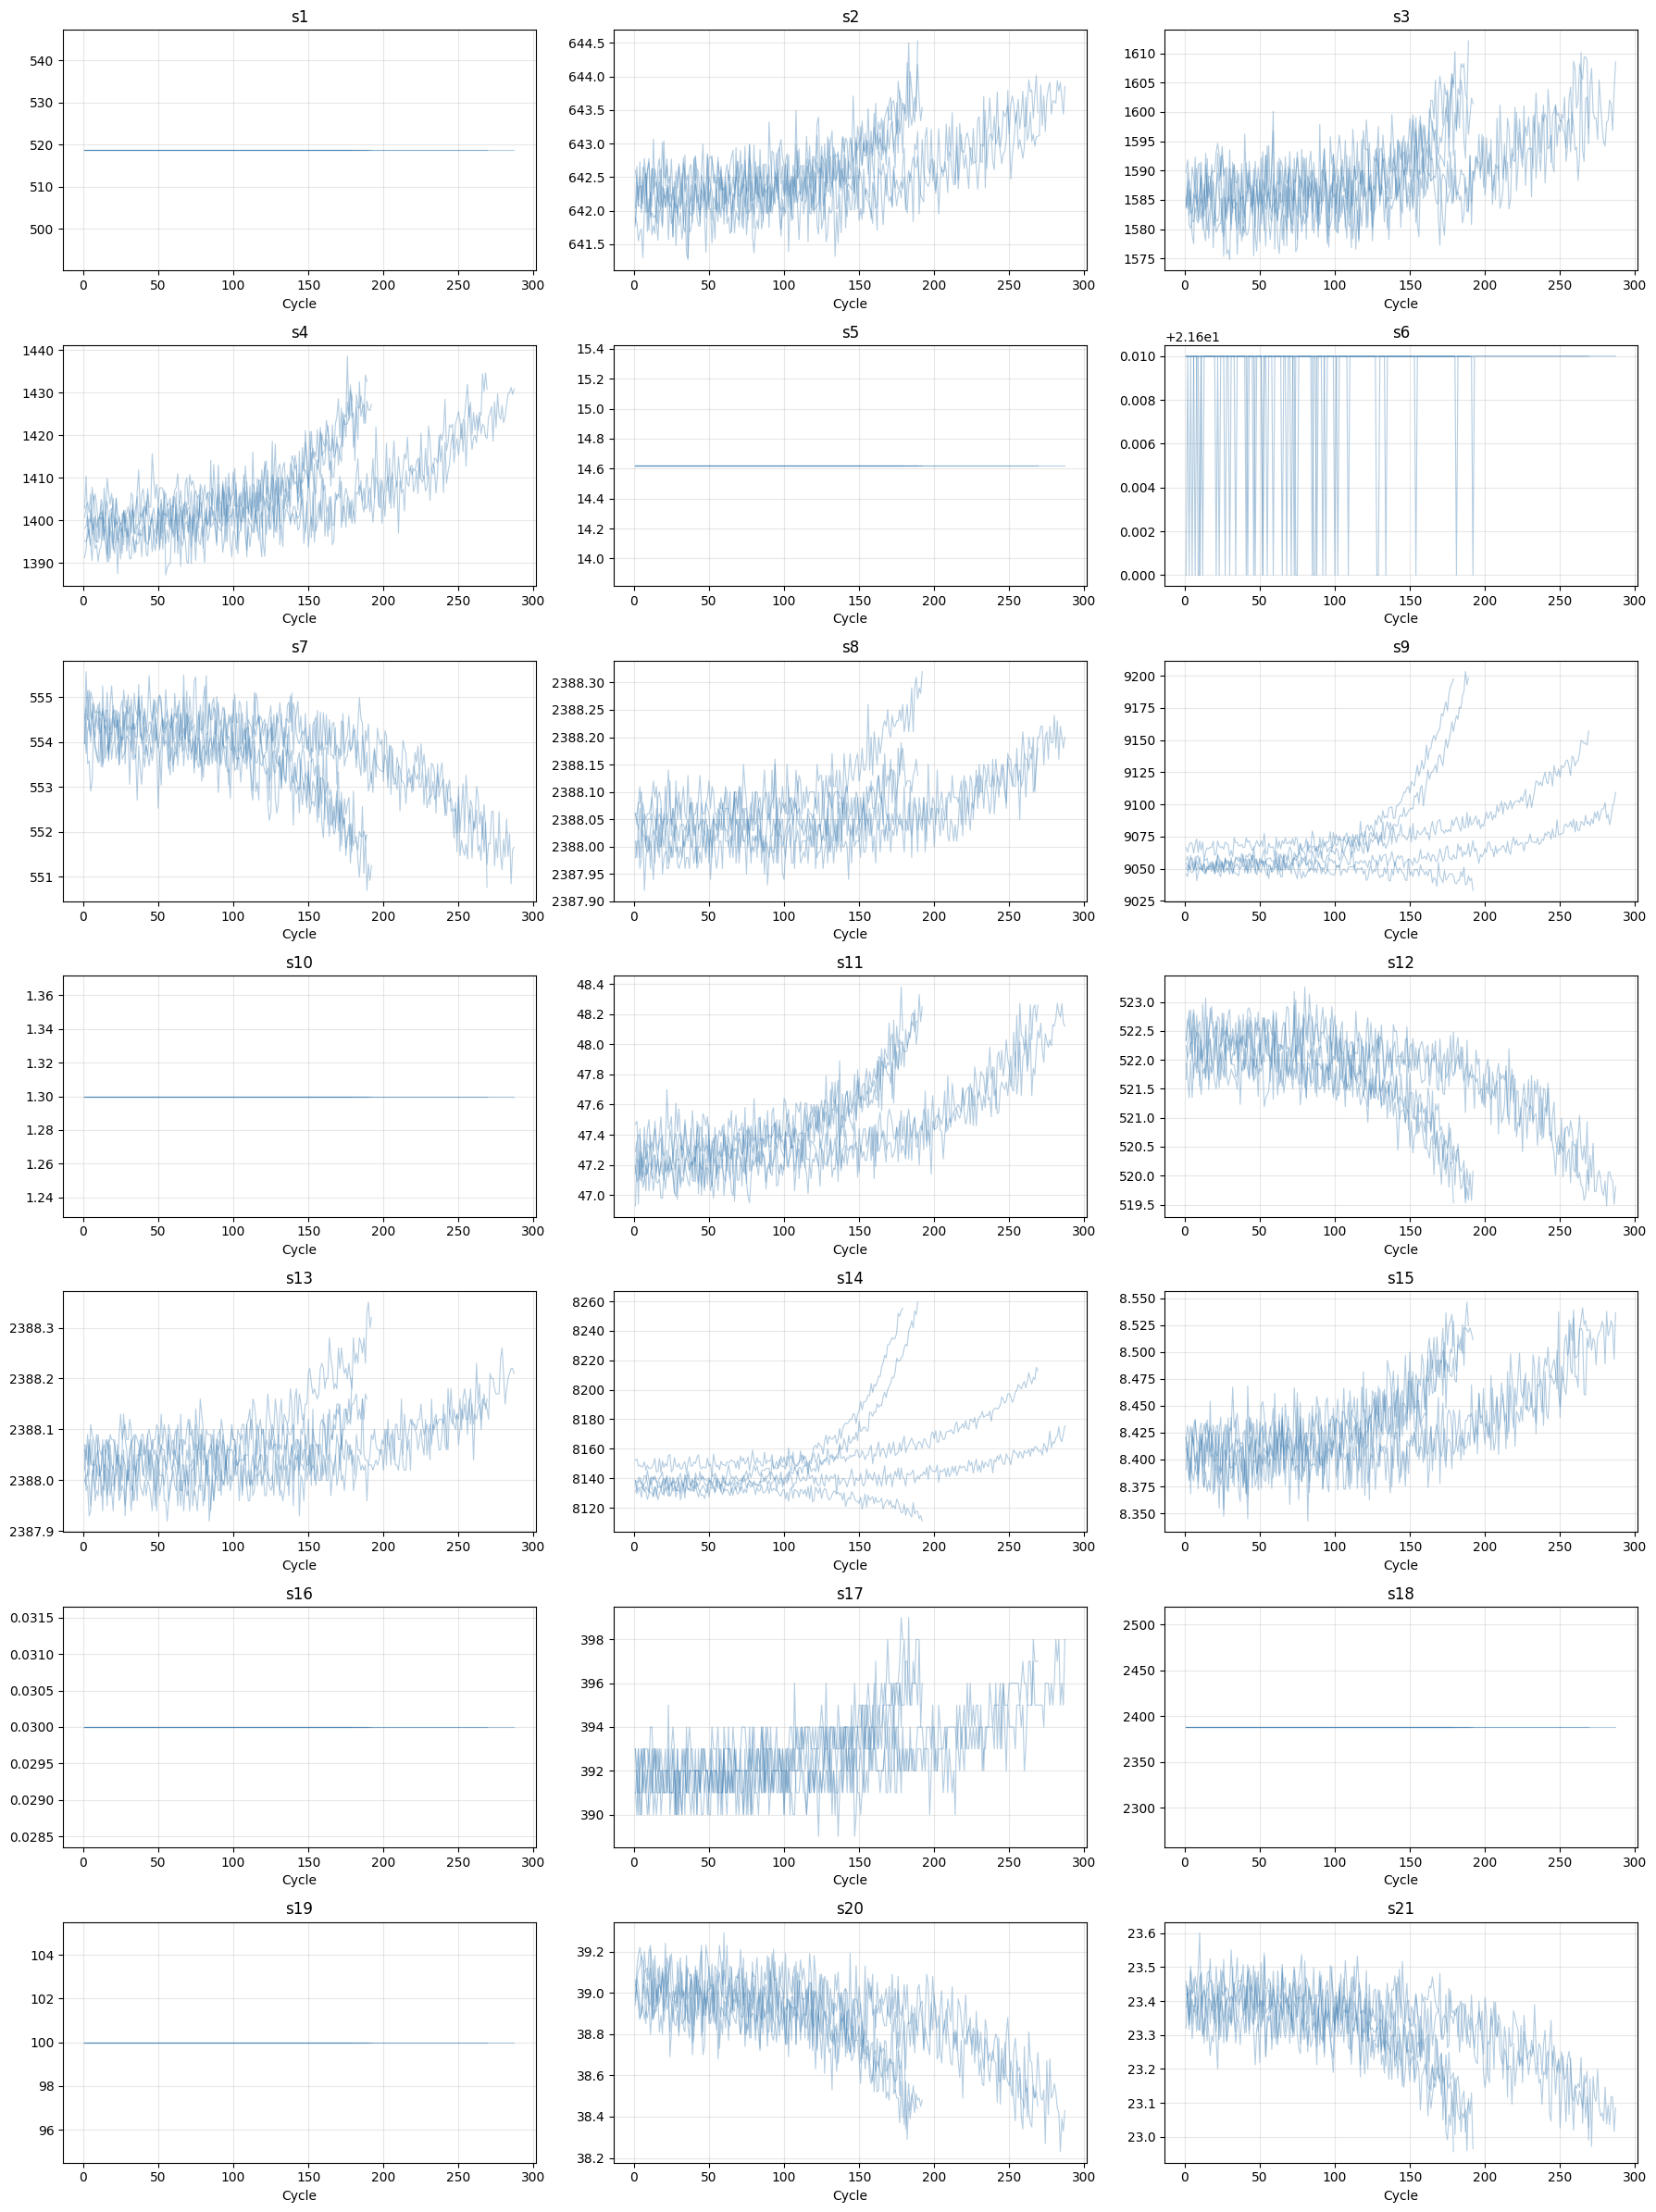

In [7]:
sensor_cols = [f's{i}' for i in range(1, 22)]

fig, axes = plt.subplots(7, 3, figsize=(18, 24))
axes = axes.flatten()

for i, sensor in enumerate(sensor_cols):
    # Plot first 5 engines in light grey, so you can see the pattern
    for engine_id in range(1, 6):
        engine_data = df[df['engine_id'] == engine_id]
        axes[i].plot(engine_data['cycle'], engine_data[sensor], 
                     alpha=0.4, color='steelblue', linewidth=0.8)
    
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Cycle')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
#standard deviation for each sensor
sensor_std = df[sensor_cols].std()
print(sensor_std.sort_values())
flat_sensors = sensor_std[sensor_std < 0.01].index.tolist()
print("Dropping:", flat_sensors)

useful_sensors = [s for s in sensor_cols if s not in flat_sensors]
print("Keeping:", useful_sensors)
print(f"Reduced from {len(sensor_cols)} to {len(useful_sensors)} sensors")

s1     0.000000e+00
s19    0.000000e+00
s18    0.000000e+00
s10    0.000000e+00
s16    1.387812e-17
s5     1.776400e-15
s6     1.388985e-03
s15    3.750504e-02
s8     7.098548e-02
s13    7.191892e-02
s21    1.082509e-01
s20    1.807464e-01
s11    2.670874e-01
s2     5.000533e-01
s12    7.375534e-01
s7     8.850923e-01
s17    1.548763e+00
s3     6.131150e+00
s4     9.000605e+00
s14    1.907618e+01
s9     2.208288e+01
dtype: float64
Dropping: ['s1', 's5', 's6', 's10', 's16', 's18', 's19']
Keeping: ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Reduced from 21 to 14 sensors


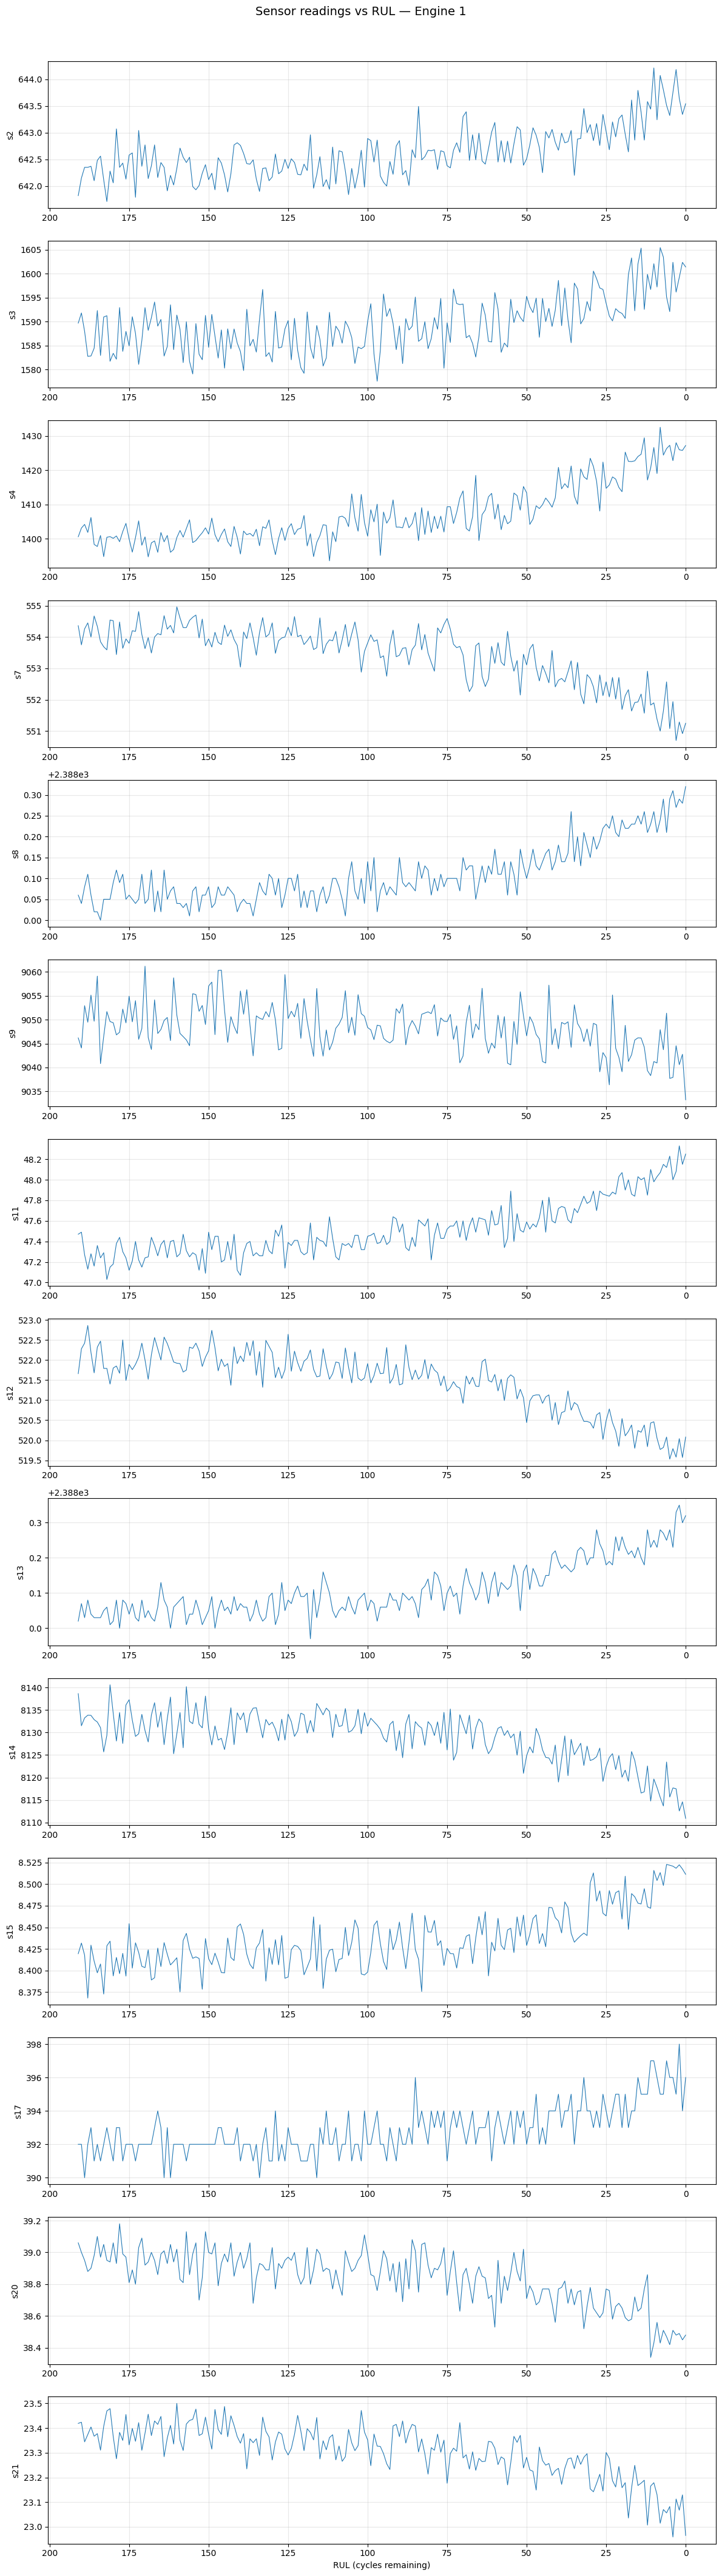

In [9]:
fig, axes = plt.subplots(len(useful_sensors), 1, figsize=(12, len(useful_sensors)*3))

for i, sensor in enumerate(useful_sensors):
    engine_1 = df[df['engine_id'] == 1]
    axes[i].plot(engine_1['RUL'], engine_1[sensor], linewidth=0.8)
    axes[i].set_ylabel(sensor)
    axes[i].invert_xaxis()  # RUL goes from high to 0, so flip x-axis
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('RUL (cycles remaining)')
plt.suptitle('Sensor readings vs RUL — Engine 1', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()